In [41]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

In [16]:
root = "/home/acomajuncosa/Documents_GPU/mtb-targeted-protein-degradation/notebooks"

In [22]:
pairs_filtered = pd.read_csv(os.path.join(root, "..", "processed", "protein_prioritization", "pairs_filtered.tsv"), sep='\t')
# pairs_filtered[(pairs_filtered['global_similarity'] == 0) & (pairs_filtered['catalytic_counts'] == 0)]

# Load pocket info
PATH_TO_RESULTS = "/aloy/home/acomajuncosa/Ersilia/gcadda4tb-enamine-real-screening/results"
POCKETS = sorted(set(sorted([i.split("_ind_")[0] for i in sorted(os.listdir(os.path.join(PATH_TO_RESULTS, "Enamine_REAL_LeadLike_000")))])))

perc = "1"

In [33]:
INTERESTING_POCKETS = {}
INTERESTING_POCKETS['GS_0_CAT_0'] = set([tuple(sorted(i)) for i in pairs_filtered[(pairs_filtered['global_similarity'] == 0) & (pairs_filtered['catalytic_counts'] == 0)][['Pocket1', 'Pocket2']].values])
INTERESTING_POCKETS['GS_0_CAT_1'] = set([tuple(sorted(i)) for i in pairs_filtered[(pairs_filtered['global_similarity'] == 0) & (pairs_filtered['catalytic_counts'] == 1)][['Pocket1', 'Pocket2']].values])
INTERESTING_POCKETS['GS_0_CAT_2'] = set([tuple(sorted(i)) for i in pairs_filtered[(pairs_filtered['global_similarity'] == 0) & (pairs_filtered['catalytic_counts'] == 2)][['Pocket1', 'Pocket2']].values])
INTERESTING_POCKETS['GS_1_CAT_0'] = set([tuple(sorted(i)) for i in pairs_filtered[(pairs_filtered['global_similarity'] == 1) & (pairs_filtered['catalytic_counts'] == 0)][['Pocket1', 'Pocket2']].values])
INTERESTING_POCKETS['GS_1_CAT_1'] = set([tuple(sorted(i)) for i in pairs_filtered[(pairs_filtered['global_similarity'] == 1) & (pairs_filtered['catalytic_counts'] == 1)][['Pocket1', 'Pocket2']].values])
INTERESTING_POCKETS['GS_1_CAT_2'] = set([tuple(sorted(i)) for i in pairs_filtered[(pairs_filtered['global_similarity'] == 1) & (pairs_filtered['catalytic_counts'] == 2)][['Pocket1', 'Pocket2']].values])

In [35]:
[[i, len(INTERESTING_POCKETS[i])] for i in INTERESTING_POCKETS]

[['GS_0_CAT_0', 94],
 ['GS_0_CAT_1', 574],
 ['GS_0_CAT_2', 787],
 ['GS_1_CAT_0', 3],
 ['GS_1_CAT_1', 23],
 ['GS_1_CAT_2', 0]]

In [23]:
# For each chunk
for chunk in ["Enamine_REAL_LeadLike_000"]:

    TOPs = {}
    SHARED_HITS = []

    # For each pocket
    for pocket in tqdm(POCKETS):

        # Get indices at specified percentile
        inds = np.load(os.path.join(PATH_TO_RESULTS, chunk, f"{pocket}_ind_{perc}.npz"))[f"ind_{perc}"]
        cut = float(np.load(os.path.join(PATH_TO_RESULTS, chunk, f"{pocket}_ind_{perc}.npz"))["thr"])

        # Store indices
        TOPs[pocket] = set(inds.tolist())

100%|██████████| 276/276 [01:45<00:00,  2.61it/s]


In [38]:
# Evaluate shared hits among pairs
INTERESTING_POCKETS_INTERSECTION = {i: [] for i in sorted(INTERESTING_POCKETS)}

# Calculate intersections
for c1, pocket1 in tqdm(enumerate(sorted(TOPs))):
    for pocket2 in sorted(TOPs)[c1+1:]:
        for s in INTERESTING_POCKETS:
            if (pocket1, pocket2) in INTERESTING_POCKETS[s]:
                intersection = len(TOPs[pocket1].intersection(TOPs[pocket2]))
                INTERESTING_POCKETS_INTERSECTION[s].append(intersection)

276it [00:05, 49.77it/s] 


In [40]:
[[i, len(INTERESTING_POCKETS[i])] for i in INTERESTING_POCKETS]

[['GS_0_CAT_0', 94],
 ['GS_0_CAT_1', 574],
 ['GS_0_CAT_2', 787],
 ['GS_1_CAT_0', 3],
 ['GS_1_CAT_1', 23],
 ['GS_1_CAT_2', 0]]

/home/acomajuncosa/miniconda3/envs/adda4tb/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


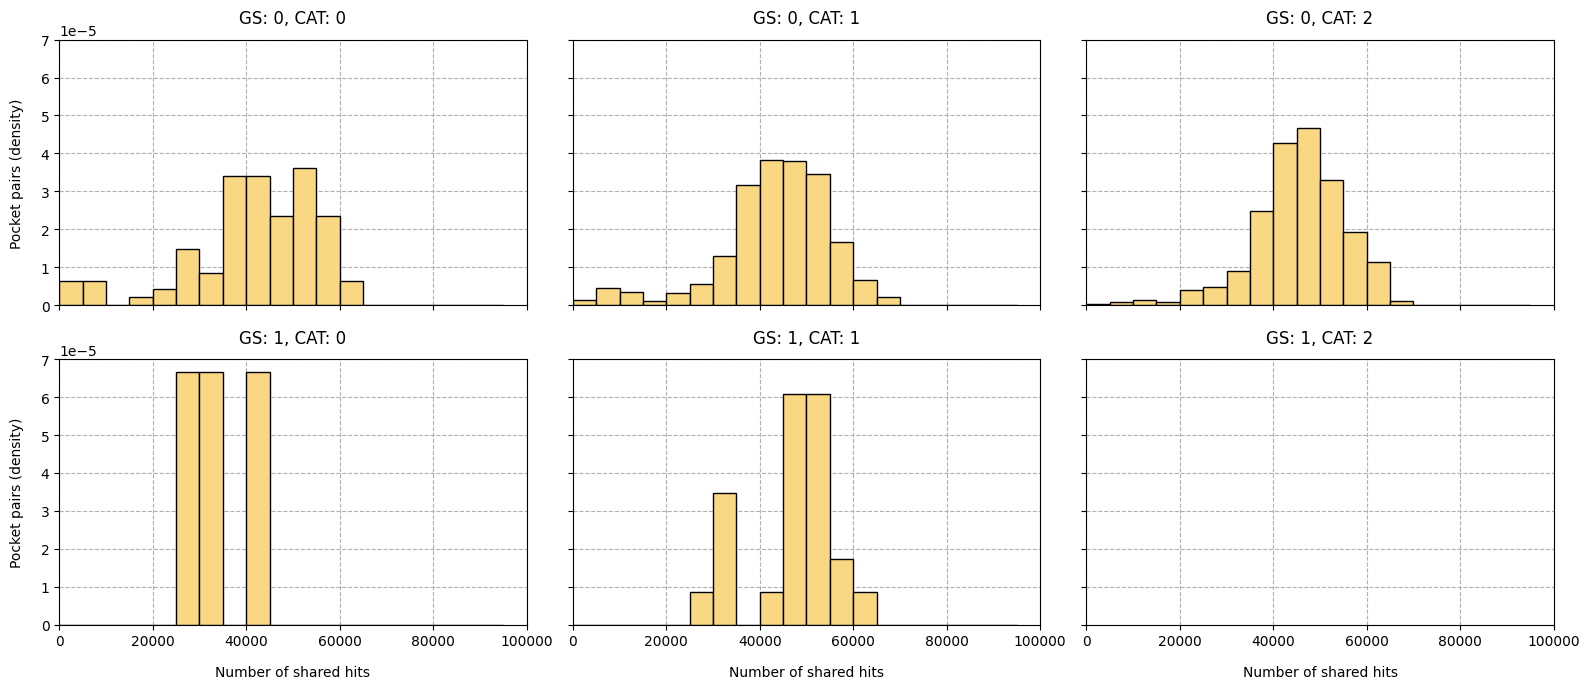

In [65]:
fig, ax = plt.subplots(2, 3, figsize=(16, 7), sharey=True, sharex=True)
bins = [i for i in range(0, 100_000, 5_000)]

for c1 in range(2):
    for c2 in range(3):
        
        h = INTERESTING_POCKETS_INTERSECTION[f"GS_{c1}_CAT_{c2}"]

        ax[c1][c2].set_title(f"GS: {c1}, CAT: {c2}", pad=12)
        ax[c1][c2].hist(h, bins=bins, edgecolor='k', linewidth=1, zorder=2, density=True, color="#FAD782")
        ax[c1][c2].grid(linestyle='--', zorder=-2)
        ax[c1][c2].set_xlim([0, 100_000])
        if c2 == 0: ax[c1][c2].set_ylabel("Pocket pairs (density)", labelpad=12)
        if c1 == 1: ax[c1][c2].set_xlabel("Number of shared hits", labelpad=12)


plt.tight_layout()
plt.show()